In [7]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

In [14]:
rng = np.random.default_rng(41)

# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")

intensity_data = final_allrisk_ds['intensity']
duration_data = final_allrisk_ds['duration']

intensity_annual = final_allrisk_ds.set_index('year_start')['intensity'].copy()

# Fill in zeros for years with no observations.
all_years = pd.Series(range(1900, 2023 + 1))
intensity_annual = intensity_annual.reindex(all_years, fill_value=0)

In [15]:
def build_model(intensity_obs,         # 1-D array (nan if no pandemic that year)
                mu=0.01,                # location / threshold
                xi_lower=-0.99,        # numerical guard: keeps 1+xi > 0
                xi_upper=5.0):         # change if you need fatter tails

    """
    PyMC model for:
        • Annual Bernoulli outbreak process with prob p
        • Conditional GPD(μ, σ, ξ) intensity
        • Reference prior  π(ξ, θ) ∝ (1+ξ)^(-1) θ^(-1),  θ = (1+ξ)·σ
    Parameters
    ----------
    intensity_obs : array_like
        Observed intensities; use np.nan where no pandemic occurred.
    outbreak_obs  : array_like of {0,1}
        1 if a pandemic occurred that year, 0 otherwise.
    mu : float
        GPD threshold / location (you can also turn this into a random var).
    """

    intensity_obs = np.asarray(intensity_obs, dtype=float)
    excess_idx = intensity_obs > mu

    with pm.Model() as m:

        # ──────────────────────────────────────────────────────────────
        # 1.  Outbreak-arrival probability  p
        #     (Jeffreys prior Beta(½,½) is a common non-informative choice)
        # ──────────────────────────────────────────────────────────────
        p = pm.Beta('p', alpha=0.5, beta=0.5)
        pm.Bernoulli('outbreak', p=p, observed=excess_idx) # Likelihood for the (0/1) indicator vector

        # ──────────────────────────────────────────────────────────────
        # 2.  GPD parameters with the *reference prior*  (1+ξ)^-1 θ^-1
        #     We do NOT add any *extra* density here – only a truncation
        # ──────────────────────────────────────────────────────────────
        # ― Shape parameter ξ  (flat within bounds ⇒ no extra log-density)
        xi = pm.Uniform('xi', lower=xi_lower, upper=xi_upper)

        # ― Log-scale for θ so that θ = exp(log_theta) is automatically >0
        log_theta = pm.Flat('log_theta')          # improper uniform on ℝ
        theta     = pm.Deterministic('theta', pt.exp(log_theta))

        # ― Translate θ back to the usual scale parameter σ
        sigma = pm.Deterministic('sigma', theta / (1.0 + xi))

        # ― Reference prior contribution  (log of (1+ξ)^-1 θ^-1)
        pm.Potential('ref_prior', -(pt.log1p(xi) + log_theta))

        # ──────────────────────────────────────────────────────────────
        # 3.  Intensity likelihood, *conditionally* on outbreak = 1
        #     (centre or non-centre both work – see comments below)
        # ──────────────────────────────────────────────────────────────
        #
        # Here we use PyMC’s built-in GPD for the likelihood because it
        # automatically handles gradients, Jacobians, etc.  A pure
        # non-centred version would replace this line with a custom
        # transformation from   u ∼ Uniform(0,1)  →  y  via the inverse CDF
        # and then treat y as observed.  In practice that buys you the
        # same geometry improvements while keeping the code shorter.

        excesses = intensity_obs[excess_idx]
        num_excesses = len(excesses)

        z   = (excesses - mu) / sigma
        eps = 1e-6
        
        logJ = pt.switch(
            pt.abs(xi) > eps,
            -pt.log(sigma) - (1 + 1/xi) * pt.log1p(xi * z),
            -pt.log(sigma) - z,
        )

        pm.Potential('unit_interval',             # ensures  0 < u < 1
            pt.sum(pt.switch((1 + xi * z) > 0, 0, -np.inf))
        )
        pm.Potential('gpd_logp', logJ.sum())
        
    return m

In [ ]:
model = build_model(intensity_annual)

with model:
    idata = pm.sample(tune=2000, draws=3000, target_accept=0.9, chains=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p, xi, log_theta]


Output()

In [8]:
posterior = idata.posterior

array([[<Axes: ylabel='sigma'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='p'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='xi', ylabel='theta'>, <Axes: xlabel='sigma'>,
        <Axes: xlabel='p'>]], dtype=object)

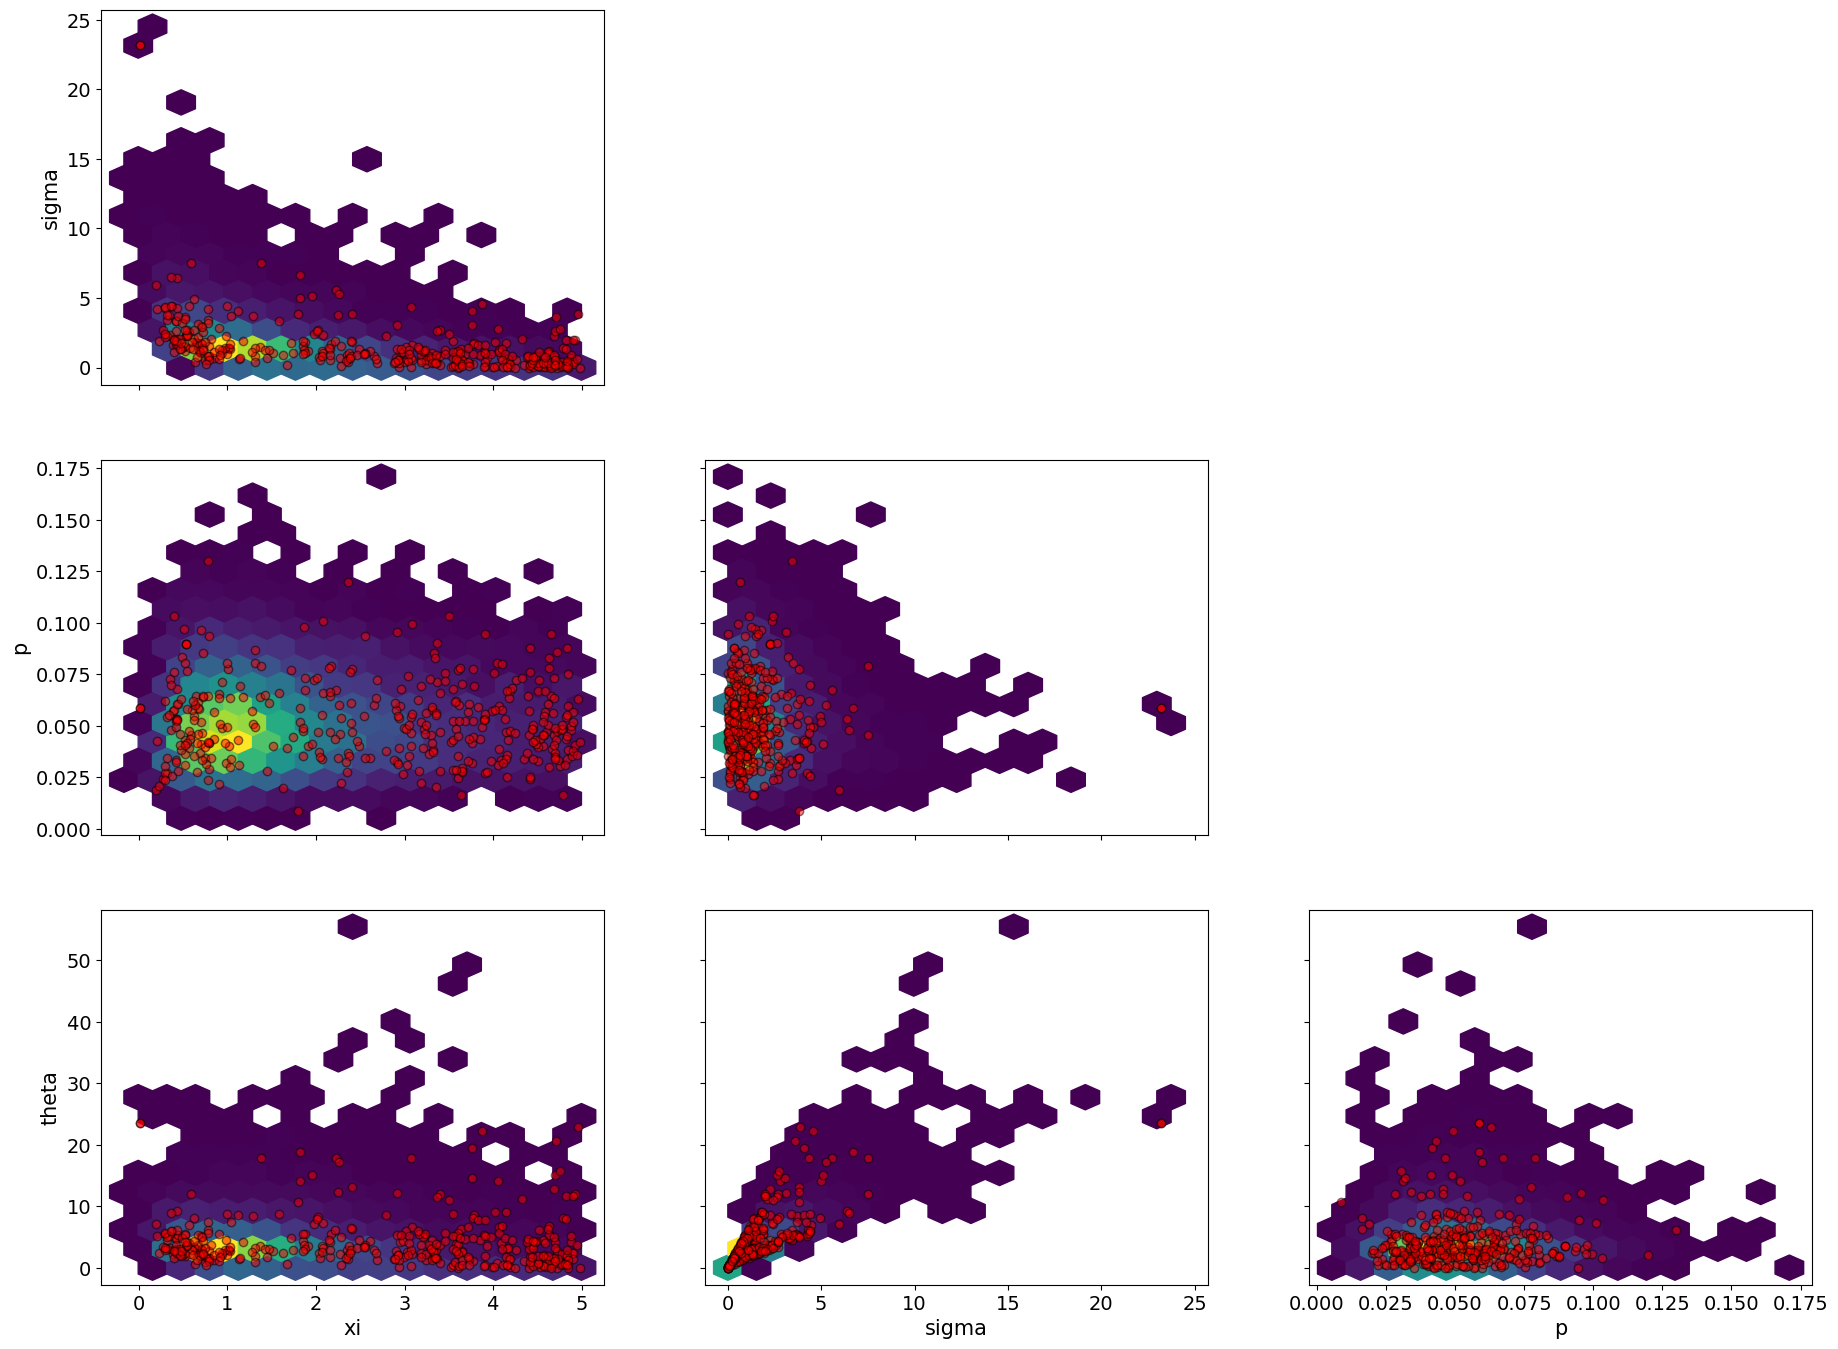

In [9]:
# Create a list of variable names for plotting
var_names = ['xi', 'sigma', 'p', 'theta']

# Create a pair plot using arviz
az.plot_pair(
    idata,
    var_names=var_names,
    kind='hexbin',
    divergences=True,
    divergences_kwargs={'color': 'r', 'alpha': 0.5}
)